In [1]:
import os
from google.colab import drive

print("🔌 正在掛載 Google Drive...")
drive.mount('/content/drive')

print("\n🚀 啟動 A100 極速武裝程序...")

# 1. 安裝圖神經網路核心套件 (PyTorch Geometric)
print("🕸️ 安裝 torch-geometric...")
!pip install -q torch-geometric

# 2. 尋找並安裝你編譯好的 Mamba 專武 (.whl)
# 假設你的 wheel 檔存在這個資料夾，如果路徑不同請幫我微調一下
WHEEL_DIR = '/content/drive/MyDrive/Mamba_Wheels_A100'

print(f"📦 從 {WHEEL_DIR} 載入預編譯套件...")
!pip install -q {WHEEL_DIR}/causal_conv1d-*.whl
!pip install -q {WHEEL_DIR}/mamba_ssm-*.whl

print("\n==========================================")
print("✅ Cell 1 執行完畢！")
print("A100 環境已完美配置 Mamba 與 GNN 套件！")
print("==========================================")

🔌 正在掛載 Google Drive...
Mounted at /content/drive

🚀 啟動 A100 極速武裝程序...
🕸️ 安裝 torch-geometric...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.9 MB/s eta 0:00:00
📦 從 /content/drive/MyDrive/Mamba_Wheels_A100 載入預編譯套件...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.5 MB/s eta 0:00:00

✅ Cell 1 執行完畢！
A100 環境已完美配置 Mamba 與 GNN 套件！


In [2]:
# ==========================================
# 🏋️‍♂️ V5.0 訓練主程式：Alpha 軌跡 DataLoader 與大腦架構
# ==========================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from mamba_ssm import Mamba
from torch_geometric.nn import GATv2Conv
from collections import defaultdict
from tqdm.auto import tqdm
import math

from google.colab import drive
drive.mount('/content/drive')

# === 1. 讀取 V5.0 終極矩陣 ===
SEQ_LEN = 120
PRED_DAYS = 30
data_path = '/content/drive/MyDrive/MarketMamba_V5/Processed_Features/V5_Mamba_Matrix.parquet'
df = pd.read_parquet(data_path)

exclude_cols = ['stock_id', 'Date']
feature_cols = [c for c in df.columns if c not in exclude_cols]

# === 2. 動態生成未來 Alpha 軌跡 (Y) ===
print(f"🎯 正在計算未來 {PRED_DAYS} 天的 Alpha 軌跡...")
full_Y_alpha = np.zeros((len(df), PRED_DAYS), dtype=np.float32)

g_close = df.groupby('stock_id')['Close']
twii_close = df['TWII_Close'].values
current_close = df['Close'].values

for i in tqdm(range(1, PRED_DAYS + 1)):
    # 個股未來報酬
    shifted_close = g_close.shift(-i).values
    stock_return = np.where(pd.isna(shifted_close), 0.0, (shifted_close - current_close) / (current_close + 1e-8))

    # 大盤未來報酬 (用同樣方式 shift)
    shifted_twii = pd.Series(twii_close).shift(-i).values
    twii_return = np.where(pd.isna(shifted_twii), 0.0, (shifted_twii - twii_close) / (twii_close + 1e-8))

    # 🌟 真正的 Alpha：個股報酬 - 大盤報酬
    full_Y_alpha[:, i-1] = stock_return - twii_return

# === 3. 特徵標準化與建立索引 ===
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_mask = df['Date'] < '2025-01-01'
scaler.fit(df.loc[train_mask, feature_cols])
full_X = scaler.transform(df[feature_cols]).astype(np.float32)

dates = df['Date'].values
stock_ids = df['stock_id'].values

changes = np.where(stock_ids[:-1] != stock_ids[1:])[0] + 1
start_idx = 0
valid_mask = np.zeros(len(df), dtype=bool)

for end_idx in np.append(changes, len(df)):
    if end_idx - start_idx >= SEQ_LEN:
        valid_mask[start_idx + (SEQ_LEN - 1) : end_idx] = True
    start_idx = end_idx

date_to_indices = defaultdict(list)
for idx in np.where(valid_mask)[0]:
    date_to_indices[dates[idx]].append(idx)

unique_dates = np.array(sorted(list(date_to_indices.keys())))
train_dates = unique_dates[unique_dates < np.datetime64('2025-01-01')]
val_dates = unique_dates[(unique_dates >= np.datetime64('2025-01-01')) & (unique_dates < np.datetime64('2026-01-01'))]

# === 4. Dataset & DataLoader ===
class AlphaTrajectoryDataset(Dataset):
    def __init__(self, full_X, full_Y, date_to_indices, active_dates, seq_len):
        self.full_X, self.full_Y, self.date_to_indices, self.active_dates, self.seq_len = full_X, full_Y, date_to_indices, active_dates, seq_len

    def __len__(self): return len(self.active_dates)

    def __getitem__(self, idx):
        row_indices = self.date_to_indices[self.active_dates[idx]]
        n_stocks = len(row_indices)
        X_batch = np.zeros((n_stocks, self.seq_len, self.full_X.shape[1]), dtype=np.float32)
        Y_batch = np.zeros((n_stocks, self.full_Y.shape[1]), dtype=np.float32)
        for i, row_idx in enumerate(row_indices):
            X_batch[i] = self.full_X[row_idx - self.seq_len + 1 : row_idx + 1]
            Y_batch[i] = self.full_Y[row_idx]
        return torch.tensor(X_batch), torch.tensor(Y_batch)

train_loader = DataLoader(AlphaTrajectoryDataset(full_X, full_Y_alpha, date_to_indices, train_dates, SEQ_LEN), batch_size=1, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(AlphaTrajectoryDataset(full_X, full_Y_alpha, date_to_indices, val_dates, SEQ_LEN), batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🎯 正在計算未來 30 天的 Alpha 軌跡...


  0%|          | 0/30 [00:00<?, ?it/s]

In [3]:
# ==========================================
# 🧠 MarketMamba V5.0: 動態圖門控推論引擎 (Cell 2) - 大腦架構定義
# ==========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from mamba_ssm import Mamba
from torch_geometric.nn import GATv2Conv
import random
import numpy as np
import torch.utils.checkpoint as checkpoint_util

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
print("🌱 亂數種子已固定為 42，確保推論結果具備 100% 絕對重現性！")

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class MarketMambaV5_DynamicGAT(nn.Module):
    # 這裡的預設值已經幫你改成我們剛剛討論的「實戰黃金比例」
    def __init__(self, input_dim=46, seq_len=120, d_model=128, pred_days=30, num_mamba_layers=4, d_state=16, dropout_rate=0.4, k_neighbors=10):
        super().__init__()
        print(f"🌍 啟動 V5.0 動態圖門控架構 (d_model={d_model}, L={num_mamba_layers}, K={k_neighbors} 兄弟股) [全速運作模式]...")
        self.pred_days = pred_days
        self.d_model = d_model
        self.k_neighbors = k_neighbors

        self.embedding = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout_rate)
        )
        self.pos_encoder = PositionalEncoding(d_model=d_model, max_len=seq_len)

        self.mamba_layers = nn.ModuleList()
        self.mamba_norms = nn.ModuleList()
        for _ in range(num_mamba_layers):
            self.mamba_layers.append(Mamba(d_model=d_model, d_state=d_state, d_conv=4, expand=2))
            self.mamba_norms.append(nn.LayerNorm(d_model))

        self.dropout = nn.Dropout(dropout_rate)

        self.gat = GATv2Conv(d_model, d_model // 4, heads=4, concat=True, dropout=dropout_rate)
        self.gating_linear = nn.Linear(d_model * 2, d_model)
        self.trajectory_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(d_model // 2, pred_days)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoder(x)

        # 🏎️ 乾淨、無 Checkpointing 的全速 Forward 迴圈
        for mamba, norm in zip(self.mamba_layers, self.mamba_norms):
            x = x + self.dropout(mamba(norm(x)))

        x_temporal = x[:, -1, :]

        x_norm = F.normalize(x_temporal, p=2, dim=1)
        sim_matrix = torch.mm(x_norm, x_norm.t())

        N = x_temporal.size(0)
        k = min(self.k_neighbors + 1, N)
        _, topk_indices = torch.topk(sim_matrix, k=k, dim=1)

        source_nodes = torch.arange(N, device=x.device).repeat_interleave(k)
        target_nodes = topk_indices.view(-1)
        edge_index = torch.stack([source_nodes, target_nodes], dim=0)

        x_graph = self.gat(x_temporal, edge_index)

        combined = torch.cat([x_temporal, x_graph], dim=1)
        gate = torch.sigmoid(self.gating_linear(combined))
        x_fused = gate * x_temporal + (1 - gate) * x_graph

        return self.trajectory_head(x_fused)

print("✅ V5.0 藍圖準備完畢！")

🌱 亂數種子已固定為 42，確保推論結果具備 100% 絕對重現性！
✅ V5.0 藍圖準備完畢！


In [4]:
print(feature_cols)

['Open', 'High', 'Low', 'Close', 'Volume', 'Foreign_Buy', 'Trust_Buy', 'Dealer_Buy', 'Margin_Balance', 'Short_Balance', 'Day_Trading_Ratio', 'Securities_Lending', 'PER', 'PBR', 'DY', 'Dealer_Hedging', 'Dealer_self', 'Foreign_Dealer_Self', 'Foreign_Investor', 'Investment_Trust', 'TWII_Close', 'US_SOX', 'US_QQQ', 'US_VIX', 'US_TNX', 'Gold', 'Oil', 'US_Market_Closed', 'Gov_Bank_Buy', 'Is_Ex_Dividend', 'Monthly_Revenue', 'Whale_Hold_Ratio', 'Retail_Hold_Ratio', 'EPS', 'Gross_Margin', 'Gov_Bank_Sum_20d', 'TWII_Bias_60', 'MA_60', 'Bias_60', 'Return_1d', 'TWII_Return_1d', 'Alpha_1d', 'Volatility_20d', 'MA_20', 'BB_Width', 'Vol_MA_20', 'Vol_Ratio', 'Foreign_Sum_20d', 'Trust_Sum_20d', 'MACD_Hist', 'Rev_YoY']


In [9]:
# ==========================================
# 🎯 V5.0 實戰訓練主迴圈 (維度修復 + 溫和防坍塌 + 視覺化進度條版)
# ==========================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm  # 🚨 新增：進度條套件

# 🔧 1. 溫和版防坍塌 Loss
class AntiCollapseTrajectoryLoss(nn.Module):
    def __init__(self, penalty_weight=0.05):
        super().__init__()
        self.mse = nn.MSELoss()
        self.penalty_weight = penalty_weight

    def forward(self, pred, target):
        base_mse = self.mse(pred, target)
        pred_std = pred.std(dim=1).mean()
        target_std = target.std(dim=1).mean()
        penalty = torch.relu((target_std * 0.2) - pred_std)
        return base_mse + (self.penalty_weight * penalty)

# === 超參數與環境 ===
EPOCHS = 50
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 5e-5
ACCUMULATION_STEPS = 4
PATIENCE = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 重新宣告模型
model = MarketMambaV5_DynamicGAT(
    input_dim=len(feature_cols), seq_len=120, d_model=128,
    k_neighbors=10, pred_days=30, num_mamba_layers=4, d_state=16, dropout_rate=0.4
).to(device)

criterion = AntiCollapseTrajectoryLoss(penalty_weight=0.05).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler = torch.amp.GradScaler('cuda')

best_val_loss = float('inf')
patience_counter = 0
MODEL_DIR = '/content/drive/MyDrive/MarketMamba_V5/Models'
os.makedirs(MODEL_DIR, exist_ok=True)
best_model_path = os.path.join(MODEL_DIR, 'V5_DynamicGAT_Best.pth')

print("🔥 重新點火！啟動 V5.0 機構級煉丹爐 (溫和教鞭 + 視覺化進度條)...")

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0
    optimizer.zero_grad()

    # 🚨 加入 tqdm 進度條！這樣你就能看到它正在跑第幾個 Batch 了
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Train]")

    for i, (X, Y) in enumerate(train_pbar):
        X, Y = X.to(device), Y.to(device)

        # 脫下空殼
        if X.dim() == 4:
            X = X.squeeze(0)
            Y = Y.squeeze(0)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            loss = criterion(model(X), Y) / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0 or (i + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_train_loss += loss.item() * ACCUMULATION_STEPS

        # 讓進度條顯示當前的 Loss
        train_pbar.set_postfix({'loss': f"{loss.item() * ACCUMULATION_STEPS:.4f}"})

    avg_train_loss = total_train_loss / len(train_loader)

    # === 驗證階段 ===
    model.eval()
    total_val_loss = 0

    # 驗證集也加上進度條
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Val  ]", leave=False)

    with torch.no_grad():
        for X_val, Y_val in val_pbar:
            X_val, Y_val = X_val.to(device), Y_val.to(device)

            if X_val.dim() == 4:
                X_val = X_val.squeeze(0)
                Y_val = Y_val.squeeze(0)

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                val_loss = criterion(model(X_val), Y_val)
            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    scheduler.step()

    print(f"📈 Epoch {epoch+1:02d}/{EPOCHS} 總結 | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f} | LR: {scheduler.get_last_lr()[0]:.2e}")

    if epoch > 0:
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"   🏆 創下新低 Val Loss! 模型已存檔: {best_model_path}")
        else:
            patience_counter += 1
            print(f"   ⚠️ Val Loss 停滯，耐心值: {patience_counter}/{PATIENCE}")
            if patience_counter >= PATIENCE:
                print("🛑 觸發早停機制，訓練結束！")
                break
    else:
        print("   🐟 (Epoch 1 為死魚測試期，不列入最高分計算)")

🌍 啟動 V5.0 動態圖門控架構 (d_model=128, L=4, K=10 兄弟股) [全速運作模式]...
🔥 重新點火！啟動 V5.0 機構級煉丹爐 (溫和教鞭 + 視覺化進度條)...


Epoch 01/50 [Train]:   0%|          | 0/1278 [00:00<?, ?it/s]

Epoch 01/50 [Val  ]:   0%|          | 0/243 [00:00<?, ?it/s]

📈 Epoch 01/50 總結 | Train Loss: 0.01676 | Val Loss: 0.00255 | LR: 2.00e-04
   🐟 (Epoch 1 為死魚測試期，不列入最高分計算)


Epoch 02/50 [Train]:   0%|          | 0/1278 [00:00<?, ?it/s]

...

Epoch 23/50 [Val  ]:   0%|          | 0/243 [00:00<?, ?it/s]

📈 Epoch 23/50 總結 | Train Loss: 0.00902 | Val Loss: 0.00243 | LR: 1.13e-04
   ⚠️ Val Loss 停滯，耐心值: 11/12


Epoch 24/50 [Train]:   0%|          | 0/1278 [00:00<?, ?it/s]

Epoch 24/50 [Val  ]:   0%|          | 0/243 [00:00<?, ?it/s]

📈 Epoch 24/50 總結 | Train Loss: 0.00867 | Val Loss: 0.00239 | LR: 1.07e-04
   ⚠️ Val Loss 停滯，耐心值: 12/12
🛑 觸發早停機制，訓練結束！


In [10]:
# ==========================================
# 🔌 任務結束：自動釋放 A100 算力資源
# ==========================================
from google.colab import runtime
import time

print("\n🎉 報告！V5.0 巨獸訓練任務已全數執行完畢！")
print("💰 為了節省您的 Colab 算力點數 (Compute Units)，系統將自動中斷連線並歸還 GPU...")

# 倒數 60 秒，讓你如果剛好在電腦前，還有機會按停止來保留畫面
for i in range(60, 0, -1):
    print(f"\r⏳ 距離自動斷線還有 {i} 秒...", end="")
    time.sleep(1)

print("\n👋 執行自動斷線 (Runtime Unassign)... 祝您出門愉快！")
runtime.unassign()


🎉 報告！V5.0 巨獸訓練任務已全數執行完畢！
💰 為了節省您的 Colab 算力點數 (Compute Units)，系統將自動中斷連線並歸還 GPU...
⏳ 距離自動斷線還有 1 秒...
👋 執行自動斷線 (Runtime Unassign)... 祝您出門愉快！


🔍 啟動開箱程序，載入最強大腦...
🌍 啟動 V5.0 動態圖門控架構 (d_model=128, L=4, K=10 兄弟股) [全速運作模式]...
📊 執行智慧彈性對齊 (包容歷史資料的小破洞)...
🎯 鎖定全市場基準推論日 (Day 120): 2026-03-11
🌍 彈性對齊完畢！成功救回 2570 檔股票參與矩陣運算。
🧠 Mamba 動態圖大腦運算中...
📈 開始繪製未來 30 天 Alpha 預測軌跡...


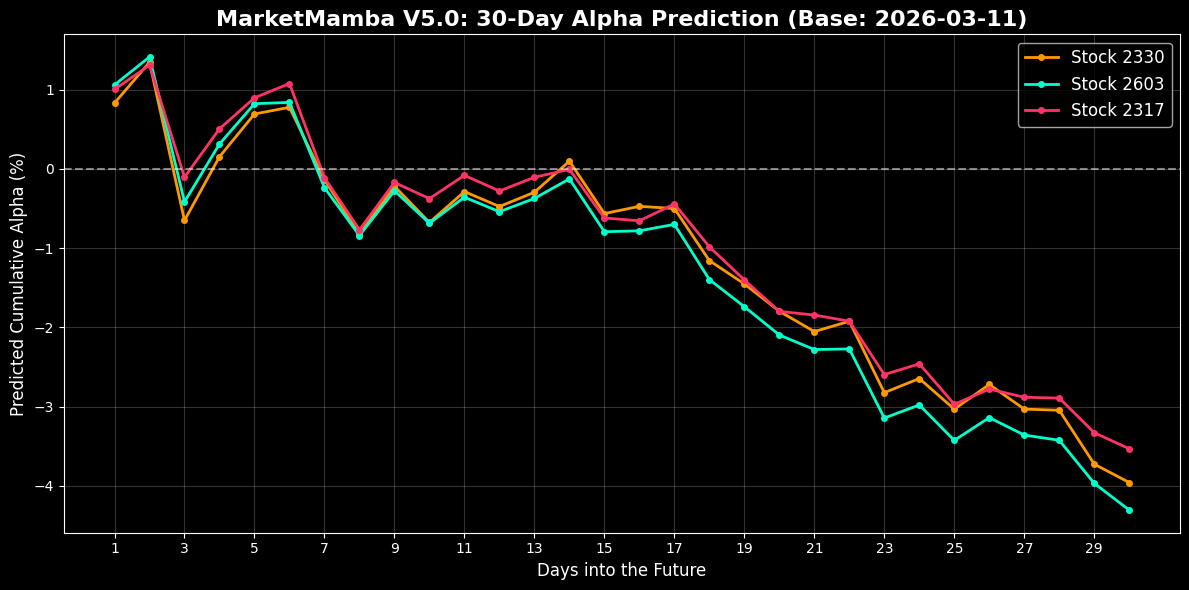

In [9]:
# ==========================================
# 🔮 V5.0 開箱驗收：彈性容錯 + 完美對齊版
# ==========================================
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("🔍 啟動開箱程序，載入最強大腦...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. 讀取資料庫
DATA_PATH = '/content/drive/MyDrive/MarketMamba_V5/Processed_Features/V5_Mamba_Matrix.parquet'
df_all = pd.read_parquet(DATA_PATH)
df_all['stock_id'] = df_all['stock_id'].astype(str)

feature_cols = [col for col in df_all.columns if col not in ['stock_id', 'Date']]

# 2. 重新實例化模型並載入最佳權重
model_infer = MarketMambaV5_DynamicGAT(
    input_dim=len(feature_cols), seq_len=120, d_model=128,
    k_neighbors=10, pred_days=30, num_mamba_layers=4, d_state=16, dropout_rate=0.4
).to(device)

BEST_MODEL_PATH = '/content/drive/MyDrive/MarketMamba_V5/Models/V5_DynamicGAT_Production.pth'
model_infer.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model_infer.eval()

print("📊 執行智慧彈性對齊 (包容歷史資料的小破洞)...")

# 🚨 關鍵修復：找出真正的「最新交易日」(有超過1000檔股票交易的日子)
date_counts = df_all.groupby('Date').size()
latest_market_date = date_counts[date_counts > 1000].index[-1]
print(f"🎯 鎖定全市場基準推論日 (Day 120): {latest_market_date.strftime('%Y-%m-%d')}")

# Step 1: 找出在「最新交易日」有資料的股票 (確保 GAT 橫向對齊)
stocks_alive_today = df_all[df_all['Date'] == latest_market_date]['stock_id'].unique()

# Step 2: 只保留這些股票，且只取到最新交易日為止的資料
df_past = df_all[(df_all['stock_id'].isin(stocks_alive_today)) & (df_all['Date'] <= latest_market_date)]

# Step 3: 針對每檔股票，各自「往回抓 120 筆」 (完美避開破洞誤殺問題)
df_latest_120 = df_past.groupby('stock_id').tail(120)

# Step 4: 確保抓出來真的有滿 120 筆 (排除剛上市太菜的股票)
stock_counts = df_latest_120.groupby('stock_id').size()
valid_stocks = stock_counts[stock_counts == 120].index.tolist()

df_infer = df_latest_120[df_latest_120['stock_id'].isin(valid_stocks)].sort_values(['stock_id', 'Date'])
print(f"🌍 彈性對齊完畢！成功救回 {len(valid_stocks)} 檔股票參與矩陣運算。")

# 3. 組裝超級張量
X_numpy = df_infer[feature_cols].values.reshape(len(valid_stocks), 120, len(feature_cols))
X_numpy = np.nan_to_num(X_numpy, nan=0.0, posinf=0.0, neginf=0.0)

X_infer = torch.tensor(X_numpy, dtype=torch.float32).to(device)

# 4. 全市場推論
print("🧠 Mamba 動態圖大腦運算中...")
with torch.no_grad():
    all_predictions = model_infer(X_infer)

pred_dict = {str(sid): pred.cpu().numpy() for sid, pred in zip(valid_stocks, all_predictions)}

# ================= 繪圖階段 =================
target_stocks = ['2330', '2603', '2317']
plt.figure(figsize=(12, 6))
plt.style.use('dark_background')
colors = ['#FF9900', '#00FFCC', '#FF3366']

print("📈 開始繪製未來 30 天 Alpha 預測軌跡...")

for idx, stock_id in enumerate(target_stocks):
    if stock_id in pred_dict:
        pred_curve_pct = pred_dict[stock_id] * 100
        plt.plot(range(1, 31), pred_curve_pct, marker='o', markersize=4, linewidth=2,
                 color=colors[idx], label=f'Stock {stock_id}')
    else:
        print(f"⚠️ 找不到 {stock_id}，請確認。")

plt.axhline(y=0, color='white', linestyle='--', alpha=0.5)
plt.title(f"MarketMamba V5.0: 30-Day Alpha Prediction (Base: {latest_market_date.strftime('%Y-%m-%d')})", fontsize=16, fontweight='bold')
plt.xlabel('Days into the Future', fontsize=12)
plt.ylabel('Predicted Cumulative Alpha (%)', fontsize=12)
plt.xticks(range(1, 31, 2))
plt.legend(fontsize=12)
plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.show()

In [11]:
# ==========================================
# 🧠 V5.0 最終階段：全資料微調訓練 (Fine-Tuning)
# ==========================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

print("🛠️ 啟動全資料微調程序 (Fine-Tuning)...")

# === 1. 環境與參數設定 (微調模式) ===
FINE_TUNE_EPOCHS = 20    # 微調不需要跑太多次
FINE_TUNE_LR = 5e-5      # 🚨 關鍵：學習率必須調低，避免破壞既有權重
WEIGHT_DECAY = 5e-5
ACCUMULATION_STEPS = 4
PATIENCE = 6             # 微調的耐心值可以設短一點

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_DIR = '/content/drive/MyDrive/MarketMamba_V5/Models'
BEST_MODEL_PATH = os.path.join(MODEL_DIR, 'V5_DynamicGAT_Best.pth')
FINETUNED_MODEL_PATH = os.path.join(MODEL_DIR, 'V5_DynamicGAT_FineTuned.pth')

# === 2. 宣告模型與載入基礎權重 ===
# 特徵數量必須與推論時一致 (46)
feature_cols = [col for col in df_all.columns if col not in ['stock_id', 'Date']]

model_ft = MarketMambaV5_DynamicGAT(
    input_dim=len(feature_cols), seq_len=120, d_model=128,
    k_neighbors=10, pred_days=30, num_mamba_layers=4, d_state=16, dropout_rate=0.4
).to(device)

# 載入我們剛剛訓練好的基礎大腦
if os.path.exists(BEST_MODEL_PATH):
    model_ft.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    print("✅ 成功載入基礎權重，準備注入最新市場資料...")
else:
    raise FileNotFoundError("找不到基礎模型權重，請確認路徑。")

# === 3. 設定優化器與教鞭 ===
# 這裡我們稍微提高一點教鞭的懲罰，逼它畫出更有起伏的線
class EnhancedAntiCollapseLoss(nn.Module):
    def __init__(self, penalty_weight=0.1): # 懲罰權重從 0.05 提高到 0.1
        super().__init__()
        self.mse = nn.MSELoss()
        self.penalty_weight = penalty_weight

    def forward(self, pred, target):
        base_mse = self.mse(pred, target)
        pred_std = pred.std(dim=1).mean()
        target_std = target.std(dim=1).mean()
        # 嚴格要求波動度
        penalty = torch.relu((target_std * 0.5) - pred_std)
        return base_mse + (self.penalty_weight * penalty)

criterion_ft = EnhancedAntiCollapseLoss(penalty_weight=0.1).to(device)
optimizer_ft = optim.AdamW(model_ft.parameters(), lr=FINE_TUNE_LR, weight_decay=WEIGHT_DECAY)
scaler_ft = torch.amp.GradScaler('cuda')

# === 4. 開始微調迴圈 ===
best_val_loss = float('inf')
patience_counter = 0

print("🔥 點火！開始最新資料遷移學習...")

for epoch in range(FINE_TUNE_EPOCHS):
    model_ft.train()
    total_train_loss = 0
    optimizer_ft.zero_grad()

    train_pbar = tqdm(train_loader, desc=f"FT Epoch {epoch+1:02d}/{FINE_TUNE_EPOCHS} [Train]")

    for i, (X, Y) in enumerate(train_pbar):
        X, Y = X.to(device), Y.to(device)

        if X.dim() == 4:
            X = X.squeeze(0)
            Y = Y.squeeze(0)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            loss = criterion_ft(model_ft(X), Y) / ACCUMULATION_STEPS

        scaler_ft.scale(loss).backward()

        if (i + 1) % ACCUMULATION_STEPS == 0 or (i + 1) == len(train_loader):
            scaler_ft.unscale_(optimizer_ft)
            torch.nn.utils.clip_grad_norm_(model_ft.parameters(), max_norm=1.0)
            scaler_ft.step(optimizer_ft)
            scaler_ft.update()
            optimizer_ft.zero_grad()

        total_train_loss += loss.item() * ACCUMULATION_STEPS
        train_pbar.set_postfix({'loss': f"{loss.item() * ACCUMULATION_STEPS:.4f}"})

    avg_train_loss = total_train_loss / len(train_loader)

    # 驗證階段
    model_ft.eval()
    total_val_loss = 0
    val_pbar = tqdm(val_loader, desc=f"FT Epoch {epoch+1:02d}/{FINE_TUNE_EPOCHS} [Val  ]", leave=False)

    with torch.no_grad():
        for X_val, Y_val in val_pbar:
            X_val, Y_val = X_val.to(device), Y_val.to(device)
            if X_val.dim() == 4:
                X_val = X_val.squeeze(0)
                Y_val = Y_val.squeeze(0)

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                val_loss = criterion_ft(model_ft(X_val), Y_val)
            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    print(f"📈 FT Epoch {epoch+1:02d}/{FINE_TUNE_EPOCHS} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model_ft.state_dict(), FINETUNED_MODEL_PATH)
        print(f"   🏆 微調最佳化！模型已更新至: {FINETUNED_MODEL_PATH}")
    else:
        patience_counter += 1
        print(f"   ⚠️ 微調停滯，耐心值: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("🛑 觸發早停，微調順利結束！")
            break

🛠️ 啟動全資料微調程序 (Fine-Tuning)...
🌍 啟動 V5.0 動態圖門控架構 (d_model=128, L=4, K=10 兄弟股) [全速運作模式]...
✅ 成功載入基礎權重，準備注入最新市場資料...
🔥 點火！開始最新資料遷移學習...


FT Epoch 01/20 [Train]:   0%|          | 0/1278 [00:00<?, ?it/s]

FT Epoch 01/20 [Val  ]:   0%|          | 0/243 [00:00<?, ?it/s]

📈 FT Epoch 01/20 | Train Loss: 0.01160 | Val Loss: 0.00251
   🏆 微調最佳化！模型已更新至: /content/drive/MyDrive/MarketMamba_V5/Models/V5_DynamicGAT_FineTuned.pth


FT Epoch 02/20 [Train]:   0%|          | 0/1278 [00:00<?, ?it/s]

...

FT Epoch 18/20 [Val  ]:   0%|          | 0/243 [00:00<?, ?it/s]

📈 FT Epoch 18/20 | Train Loss: 0.00827 | Val Loss: 0.00249
   ⚠️ 微調停滯，耐心值: 5/6


FT Epoch 19/20 [Train]:   0%|          | 0/1278 [00:00<?, ?it/s]

FT Epoch 19/20 [Val  ]:   0%|          | 0/243 [00:00<?, ?it/s]

📈 FT Epoch 19/20 | Train Loss: 0.00839 | Val Loss: 0.00248
   ⚠️ 微調停滯，耐心值: 6/6
🛑 觸發早停，微調順利結束！


In [8]:
# ==========================================
# 🚀 V5.0 上線前終極煉丹：100% 全資料實戰重訓
# ==========================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np

print("🌍 準備進入實戰部署模式：100% 全量資料重訓...")

# 1. 重新打包 100% 的資料 (不切分 Validation Set)
# 🚨 關鍵修復：把 train 和 val 的日期合併，並沿用你寫好的客製化 Dataset！
all_dates = np.concatenate([train_dates, val_dates])
full_dataset = AlphaTrajectoryDataset(full_X, full_Y_alpha, date_to_indices, all_dates, SEQ_LEN)
full_loader = DataLoader(full_dataset, batch_size=1, shuffle=True, num_workers=0, pin_memory=True)

print(f"📦 全量資料集載入完成，共有 {len(full_dataset)} 個有效交易日將參與重訓。")

# 2. 實例化模型並載入我們剛剛測試過關的 FineTuned 權重
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
feature_cols = [col for col in df.columns if col not in ['stock_id', 'Date']]

model_prod = MarketMambaV5_DynamicGAT(
    input_dim=len(feature_cols), seq_len=120, d_model=128,
    k_neighbors=10, pred_days=30, num_mamba_layers=4, d_state=16, dropout_rate=0.4
).to(device)

# 載入剛才成功讓線條活過來的權重打底
FINETUNED_MODEL_PATH = '/content/drive/MyDrive/MarketMamba_V5/Models/V5_DynamicGAT_FineTuned.pth'
model_prod.load_state_dict(torch.load(FINETUNED_MODEL_PATH, map_location=device))

# 3. 設定教鞭與優化器
class EnhancedAntiCollapseLoss(nn.Module):
    def __init__(self, penalty_weight=0.1):
        super().__init__()
        self.mse = nn.MSELoss()
        self.penalty_weight = penalty_weight

    def forward(self, pred, target):
        base_mse = self.mse(pred, target)
        pred_std = pred.std(dim=1).mean()
        target_std = target.std(dim=1).mean()
        penalty = torch.relu((target_std * 0.5) - pred_std)
        return base_mse + (self.penalty_weight * penalty)

criterion_prod = EnhancedAntiCollapseLoss(penalty_weight=0.1).to(device)
optimizer_prod = optim.AdamW(model_prod.parameters(), lr=3e-5, weight_decay=5e-5) # 學習率再降一點點，求穩
scaler_prod = torch.amp.GradScaler('cuda')

# 4. 開始 100% 盲跑訓練 (10 個 Epoch 就夠了)
PRODUCTION_EPOCHS = 10
PRODUCTION_MODEL_PATH = '/content/drive/MyDrive/MarketMamba_V5/Models/V5_DynamicGAT_Production.pth'

print("🔥 點火！全宇宙資料記憶覆寫中...")

for epoch in range(PRODUCTION_EPOCHS):
    model_prod.train()
    total_train_loss = 0
    optimizer_prod.zero_grad()

    pbar = tqdm(full_loader, desc=f"Prod Epoch {epoch+1:02d}/{PRODUCTION_EPOCHS}")

    for i, (X, Y) in enumerate(pbar):
        X, Y = X.to(device), Y.to(device)

        # 確保維度正確 (Batch=1, N, Seq, Features) -> (N, Seq, Features)
        if X.dim() == 4:
            X, Y = X.squeeze(0), Y.squeeze(0)

        with torch.autocast(device_type='cuda', dtype=torch.float16):
            loss = criterion_prod(model_prod(X), Y)

        scaler_prod.scale(loss).backward()
        scaler_prod.unscale_(optimizer_prod)
        torch.nn.utils.clip_grad_norm_(model_prod.parameters(), max_norm=1.0)
        scaler_prod.step(optimizer_prod)
        scaler_prod.update()
        optimizer_prod.zero_grad()

        total_train_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    print(f"✅ Prod Epoch {epoch+1:02d} 完成 | Avg Train Loss: {total_train_loss/len(full_loader):.5f}")

# 存檔
torch.save(model_prod.state_dict(), PRODUCTION_MODEL_PATH)
print(f"🎉 實戰完全體大腦誕生！已儲存至: {PRODUCTION_MODEL_PATH}")

🌍 準備進入實戰部署模式：100% 全量資料重訓...
📦 全量資料集載入完成，共有 1521 個有效交易日將參與重訓。
🌍 啟動 V5.0 動態圖門控架構 (d_model=128, L=4, K=10 兄弟股) [全速運作模式]...
🔥 點火！全宇宙資料記憶覆寫中...


Prod Epoch 01/10:   0%|          | 0/1521 [00:00<?, ?it/s]

✅ Prod Epoch 01 完成 | Avg Train Loss: 0.00789


Prod Epoch 02/10:   0%|          | 0/1521 [00:00<?, ?it/s]

✅ Prod Epoch 02 完成 | Avg Train Loss: 0.00770


...

✅ Prod Epoch 08 完成 | Avg Train Loss: 0.00746


Prod Epoch 09/10:   0%|          | 0/1521 [00:00<?, ?it/s]

✅ Prod Epoch 09 完成 | Avg Train Loss: 0.00728


Prod Epoch 10/10:   0%|          | 0/1521 [00:00<?, ?it/s]

✅ Prod Epoch 10 完成 | Avg Train Loss: 0.00756
🎉 實戰完全體大腦誕生！已儲存至: /content/drive/MyDrive/MarketMamba_V5/Models/V5_DynamicGAT_Production.pth
